In [355]:
##### Looks at distribution of variables to identify outliers and issues

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import matplotlib.cm as cm

In [342]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data

capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Predictors/raster_matrix.parquet")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/variable_distribution"

In [343]:
### Merge capital & labor model data 

# Merge labor model into capital model

# Columns unique to each df
capital_only_cols = ['ag_capital_stock_USD_nominal', 'capital_intensity_USD_per_USD']
labor_only_cols   = ['ag_jobs', 'labor_intensity_jobs_per_million_USD']

# Shared predictor columns (excluding keys and model-specific cols)
shared_cols = ['PROJ_ID', 'GEO_ID_NAME', 'total_production_USD', 'SOC',
               'pct_cropland_irrigated', 'female_share', 'pop_density_people_per_km2',
               'average_travel_time_city', 'average_travel_time_port',
               'probability_economic_land_use_objective', 'probability_survival_land_use_objective',
               'growing_season_length_days', 'child_dependency_ratio', 'GDP_pc', 'slope',
               'USD_production_per_HA', 'cereals_share_production_USD', 'fibres_share_production_USD',
               'fruits_share_production_USD', 'oilcrops_share_production_USD',
               'pulses_share_production_USD', 'roots_tubers_share_production_USD',
               'rest_of_crops_share_production_USD', 'sugar_crops_share_production_USD',
               'vegetables_share_production_USD', 'rubber_share_production_USD',
               'ruminants_share_production_USD', 'monogastrics_share_production_USD',
               'poultry_share_production_USD', 'other_share_production_USD', 'pct_GDP_ag',
               'share_vlarge_field', 'share_large_field', 'share_medium_field', 'share_small_field',
               'share_vsmall_field', 'share_with_nightlights', 'crop_intensity',
               'country_labor_intensity_jobs_per_million_USD', 'country_capital_intensity_USD_per_USD']

# Merge: left join brings in labor cols for matching rows, NaN for non-matches
model_combined = capital_model.merge(
    labor_model[['PROJ_ID'] + labor_only_cols],
    on='PROJ_ID',
    how='left'
)

# Rows in labor_model not in capital_model — concat with NaN capital cols
labor_only_rows = labor_model[~labor_model['PROJ_ID'].isin(capital_model['PROJ_ID'])].copy()
for col in capital_only_cols:
    labor_only_rows[col] = np.nan

model_combined = pd.concat([model_combined, labor_only_rows], ignore_index=True)

### Individual variables

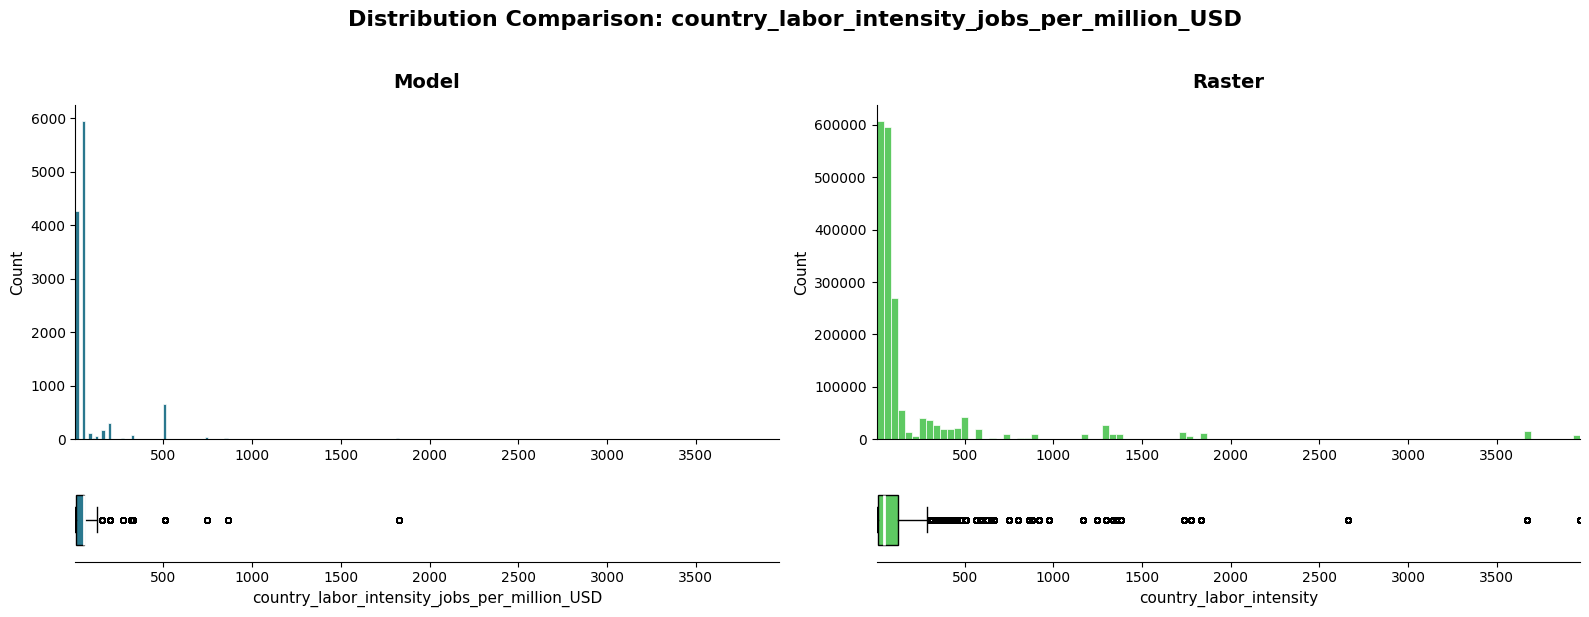

In [346]:
##### Make histogram & box-plot for individual variable 
# set variable name

model_var  = 'country_labor_intensity_jobs_per_million_USD'
raster_var = 'country_labor_intensity'

color_model  = plt.cm.viridis(0.4)
color_raster = plt.cm.viridis(0.75)

# Shared x range across both datasets
x_min = min(model_combined[model_var].min(), raster_model[raster_var].min())
x_max = max(model_combined[model_var].max(), raster_model[raster_var].max())

fig, axes = plt.subplots(2, 2, figsize=(16, 6),
                          gridspec_kw={'height_ratios': [4, 1]})

ax_hist_m, ax_hist_r = axes[0]
ax_box_m,  ax_box_r  = axes[1]

def plot_hist_box(ax_hist, ax_box, data, var_name, color, label):
    ax_hist.hist(data.dropna(), bins=100, color=color, edgecolor='white', linewidth=0.5)
    ax_hist.set_ylabel('Count', fontsize=11)
    ax_hist.set_title(f'{label}', fontsize=14, weight='bold', pad=12)
    ax_hist.spines[['top', 'right']].set_visible(False)

    ax_box.boxplot(data.dropna(), vert=False, widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=color, color='black'),
                   medianprops=dict(color='white', linewidth=2),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black', markersize=4))
    ax_box.set_xlabel(var_name, fontsize=11)
    ax_box.spines[['top', 'right', 'left']].set_visible(False)
    ax_box.set_yticks([])

plot_hist_box(ax_hist_m, ax_box_m, model_combined[model_var],  model_var,  color_model,  'Model')
plot_hist_box(ax_hist_r, ax_box_r, raster_model[raster_var],  raster_var, color_raster, 'Raster')

# Apply shared x range to all four axes after plotting
for ax in [ax_hist_m, ax_hist_r, ax_box_m, ax_box_r]:
    ax.set_xlim(x_min, x_max)

fig.suptitle(f'Distribution Comparison: {model_var}', fontsize=16, weight='bold', y=1.02)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/variables/{model_var}_dist.png", dpi=300, bbox_inches='tight')

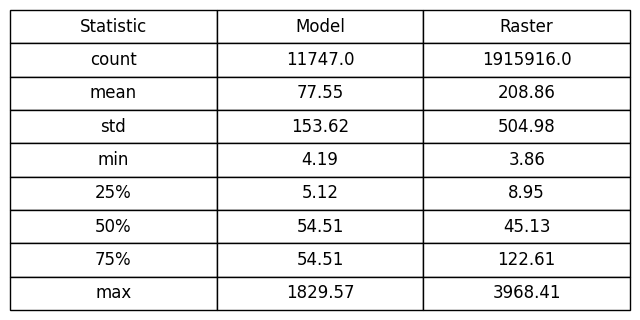

In [347]:
##### Make table of basic stats

stats_model  = model_combined[model_var].describe().round(2)
stats_raster = raster_model[raster_var].describe().round(2)

stats_df = pd.DataFrame({
    'Statistic': stats_model.index,
    'Model':   stats_model.values,
    'Raster':  stats_raster.values
})

### Create fig of table
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/variables/{model_var}_table.png", dpi=300, bbox_inches='tight')

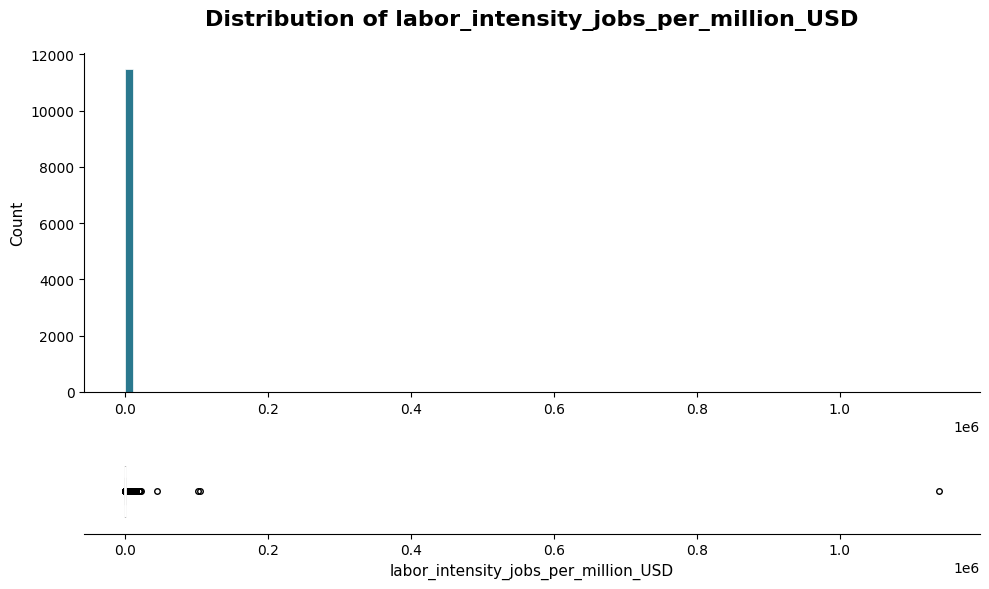

In [353]:
##### Make histogram & box-plot for individual variable (TARGET - MODEL ONLY)

model_var = 'labor_intensity_jobs_per_million_USD'

color_model = plt.cm.viridis(0.4)

fig, (ax_hist, ax_box) = plt.subplots(2, 1, figsize=(10, 6),
                                       gridspec_kw={'height_ratios': [4, 1]})

data = model_combined[model_var].dropna()

# Histogram
ax_hist.hist(data, bins=100, color=color_model, edgecolor='white', linewidth=0.5)
ax_hist.set_ylabel('Count', fontsize=11)
ax_hist.set_title(f'Distribution of {model_var}', fontsize=16, weight='bold', pad=20)
ax_hist.spines[['top', 'right']].set_visible(False)

# Boxplot
ax_box.boxplot(data, vert=False, widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor=color_model, color='black'),
               medianprops=dict(color='white', linewidth=2),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               flierprops=dict(marker='o', color=color_model,
                               markeredgecolor='black', markersize=4))
ax_box.set_xlabel(model_var, fontsize=11)
ax_box.spines[['top', 'right', 'left']].set_visible(False)
ax_box.set_yticks([])

# Align x-axes
ax_hist.set_xlim(ax_box.get_xlim())

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/variables/{model_var}_dist.png", dpi=300, bbox_inches='tight')

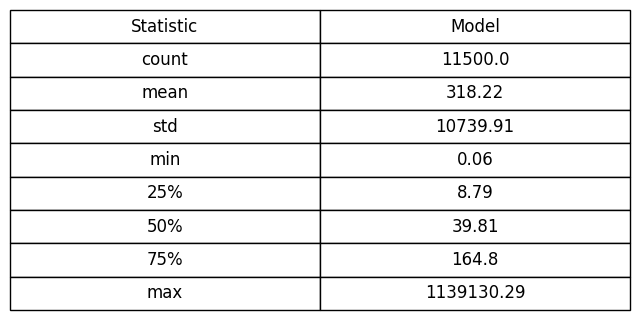

In [354]:
##### Make table of basic stats (TARGET VARIABLE - MODEL ONLY)

stats_model  = model_combined[model_var].describe().round(2)

stats_df = pd.DataFrame({
    'Statistic': stats_model.index,
    'Model':   stats_model.values
})

### Create fig of table
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/variables/{model_var}_table.png", dpi=300, bbox_inches='tight')

### Scatterplots of predictors & targets

In [364]:
##### Set styling and define figure function 

# Set pallet 
C_SCATTER = cm.viridis(0.4)   # dot fill
C_TREND   = cm.viridis(0.85)  # trend-line colour
ALPHA     = 0.35
DOT_SIZE  = 6

def _hex(r, bins=40):
    """Return (x_centres, y_centres, counts) for a 2-D hexbin density."""
    return r  # placeholder – we use hexbin directly on the axes

# Set variable groups
GROUPS = {
    "Production Shares": [
        'cereals_share_production_USD', 'fibres_share_production_USD',
        'fruits_share_production_USD',  'oilcrops_share_production_USD',
        'pulses_share_production_USD',  'roots_tubers_share_production_USD',
        'rest_of_crops_share_production_USD', 'sugar_crops_share_production_USD',
        'vegetables_share_production_USD', 'rubber_share_production_USD',
        'ruminants_share_production_USD', 'monogastrics_share_production_USD',
        'poultry_share_production_USD', 'other_share_production_USD',
    ],
    "Field Size & Land Use": [
        'share_vlarge_field', 'share_large_field', 'share_medium_field',
        'share_small_field',  'share_vsmall_field',
        'pct_cropland_irrigated',
        'probability_economic_land_use_objective',
        'probability_survival_land_use_objective',
        'crop_intensity',
    ],
    "Economic & Labour": [
        'total_production_USD', 'GDP_pc', 'pct_GDP_ag',
        'USD_production_per_HA',
        'country_labor_intensity_jobs_per_million_USD',
        'country_capital_intensity_USD_per_USD',
        'share_with_nightlights',
    ],
    "Geography & Climate": [
        'slope', 'pop_density_people_per_km2',
        'average_travel_time_city', 'average_travel_time_port',
        'growing_season_length_days',
    ],
    "Demographics": [
        'female_share', 'child_dependency_ratio', 'SOC',
    ]
}

# Define funtion for plotting
def plot_scatter_group(df, model, target, predictors, group_name, ncols=4, fd='.'):
    """
    Heatmap scatterplot (hexbin) for each predictor vs. target.
    Style mirrors the histogram/boxplot figure: viridis, bold titles,
    spine pruning, tight layout.
    """
    # Skip ID columns – not useful as numerics
    predictors = [p for p in predictors if p in df.columns
                  and pd.api.types.is_numeric_dtype(df[p])]
    if not predictors:
        print(f"[{group_name}] No numeric predictors – skipped.")
        return

    n      = len(predictors)
    nrows  = int(np.ceil(n / ncols))
    fw, fh = ncols * 3.8, nrows * 3.4

    fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh))
    axes_flat = np.array(axes).flatten()

    for i, pred in enumerate(predictors):
        ax  = axes_flat[i]
        sub = df[[pred, target]].dropna()

        x, y = sub[pred], sub[target]

        # ── Hexbin density (= heatmap scatterplot) ──────────────────────────
        hb = ax.hexbin(
            x, y,
            gridsize=30,
            cmap='viridis',
            mincnt=1,
            linewidths=0.2,
        )

        # ── OLS trend line ───────────────────────────────────────────────────
        if len(x) > 2:
            m, b   = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, m * x_line + b,
                    color=C_TREND, linewidth=1.6, linestyle='--', zorder=5)

        # ── Pearson r ────────────────────────────────────────────────────────
        r = np.corrcoef(x, y)[0, 1]
        ax.text(0.97, 0.05, f'r = {r:.2f}',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=9, color='white',
                bbox=dict(boxstyle='round,pad=0.25',
                          facecolor='#333333', alpha=0.6, edgecolor='none'))

        # ── Styling (mirrors your figure) ────────────────────────────────────
        short = pred.replace('_share_production_USD', '_share') \
                    .replace('_', ' ')
        ax.set_xlabel(short, fontsize=9)
        ax.set_ylabel(f'log({model} intensity)', fontsize=9)
        ax.set_title(short, fontsize=10, weight='bold', pad=6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    # ── Hide surplus axes ────────────────────────────────────────────────────
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # ── Shared colour-bar ────────────────────────────────────────────────────
    cbar = fig.colorbar(hb, ax=axes_flat[:i+1], shrink=0.6, pad=0.02)
    cbar.set_label('Count', fontsize=10)

    fig.suptitle(f'{group_name} vs. log({model} intensity)',
                 fontsize=14, weight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    safe_name = group_name.lower().replace(' ', '_').replace('/', '_')
    fig.savefig(f"{fd}/scatter_{safe_name}_{model}.png", dpi=300, bbox_inches='tight')

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_82831/2744293172.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


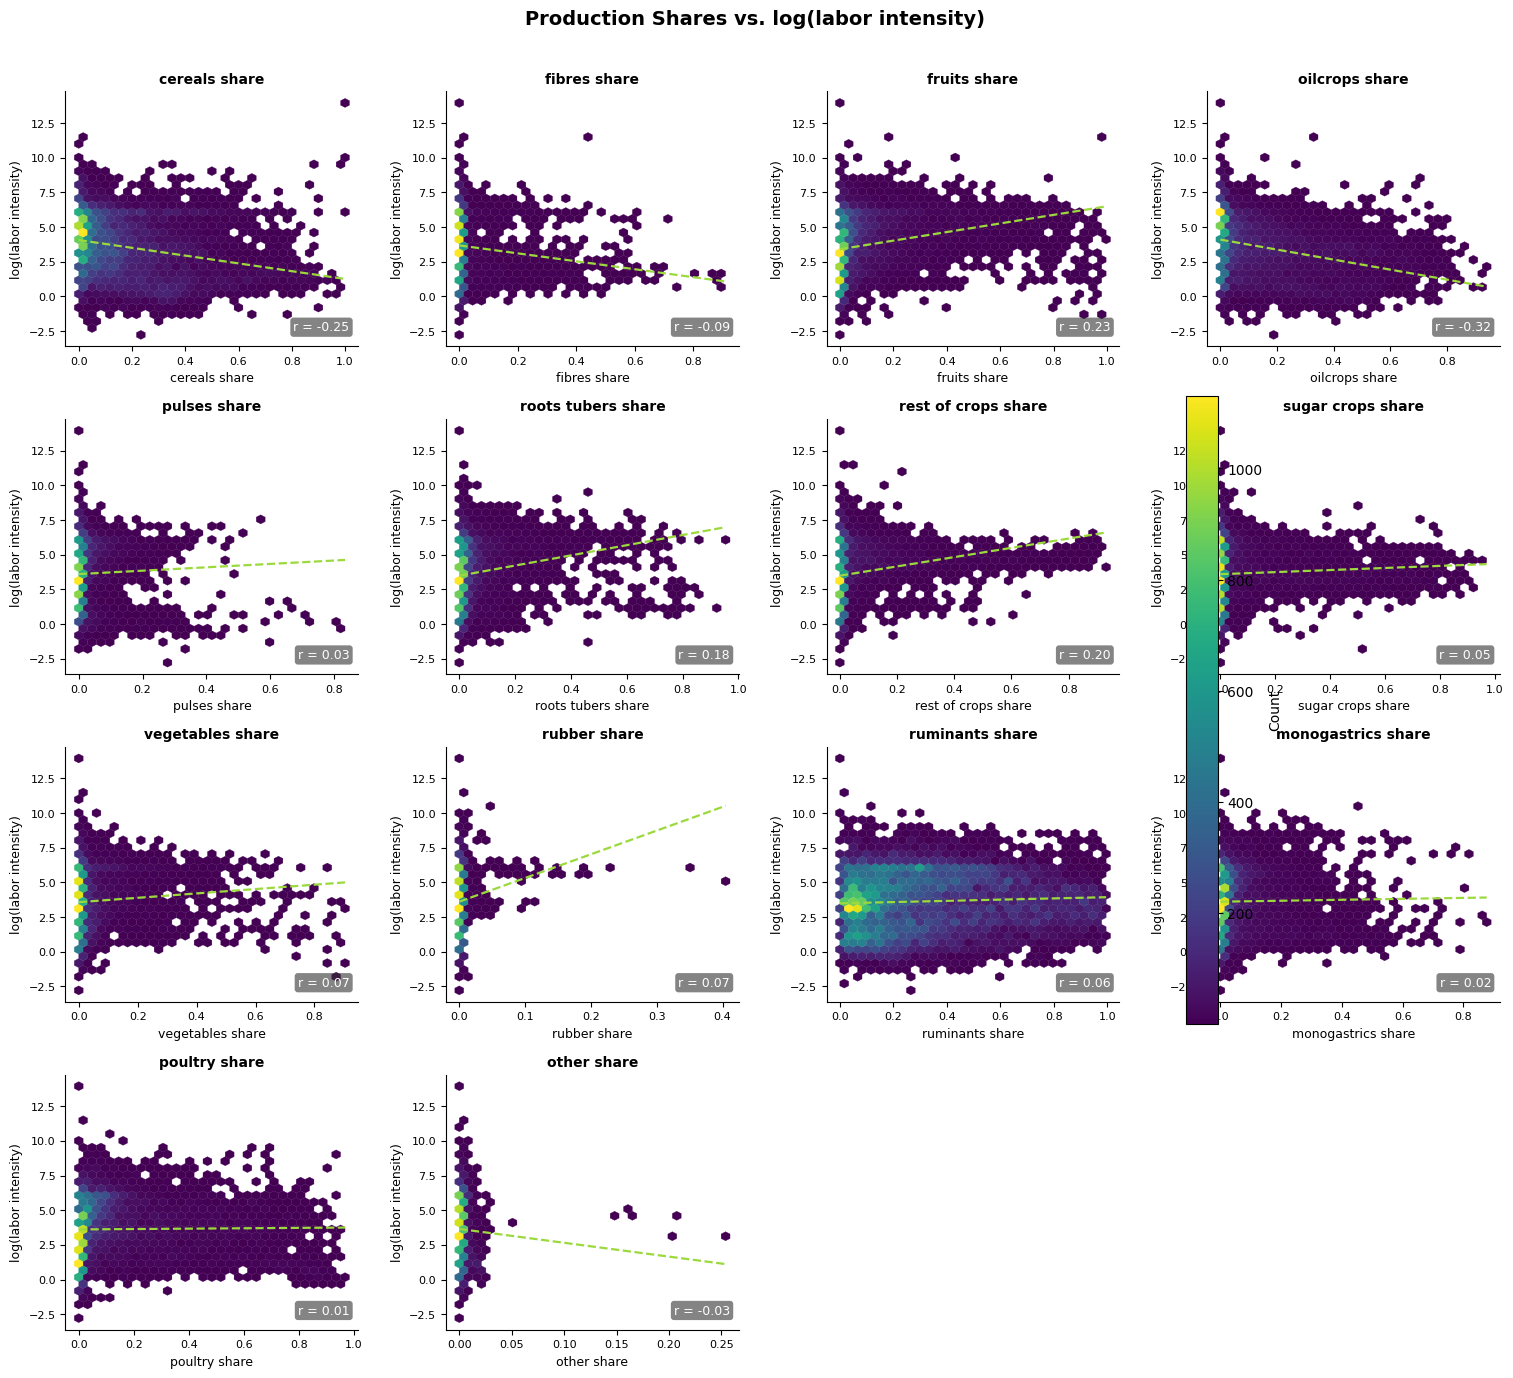

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_82831/2744293172.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


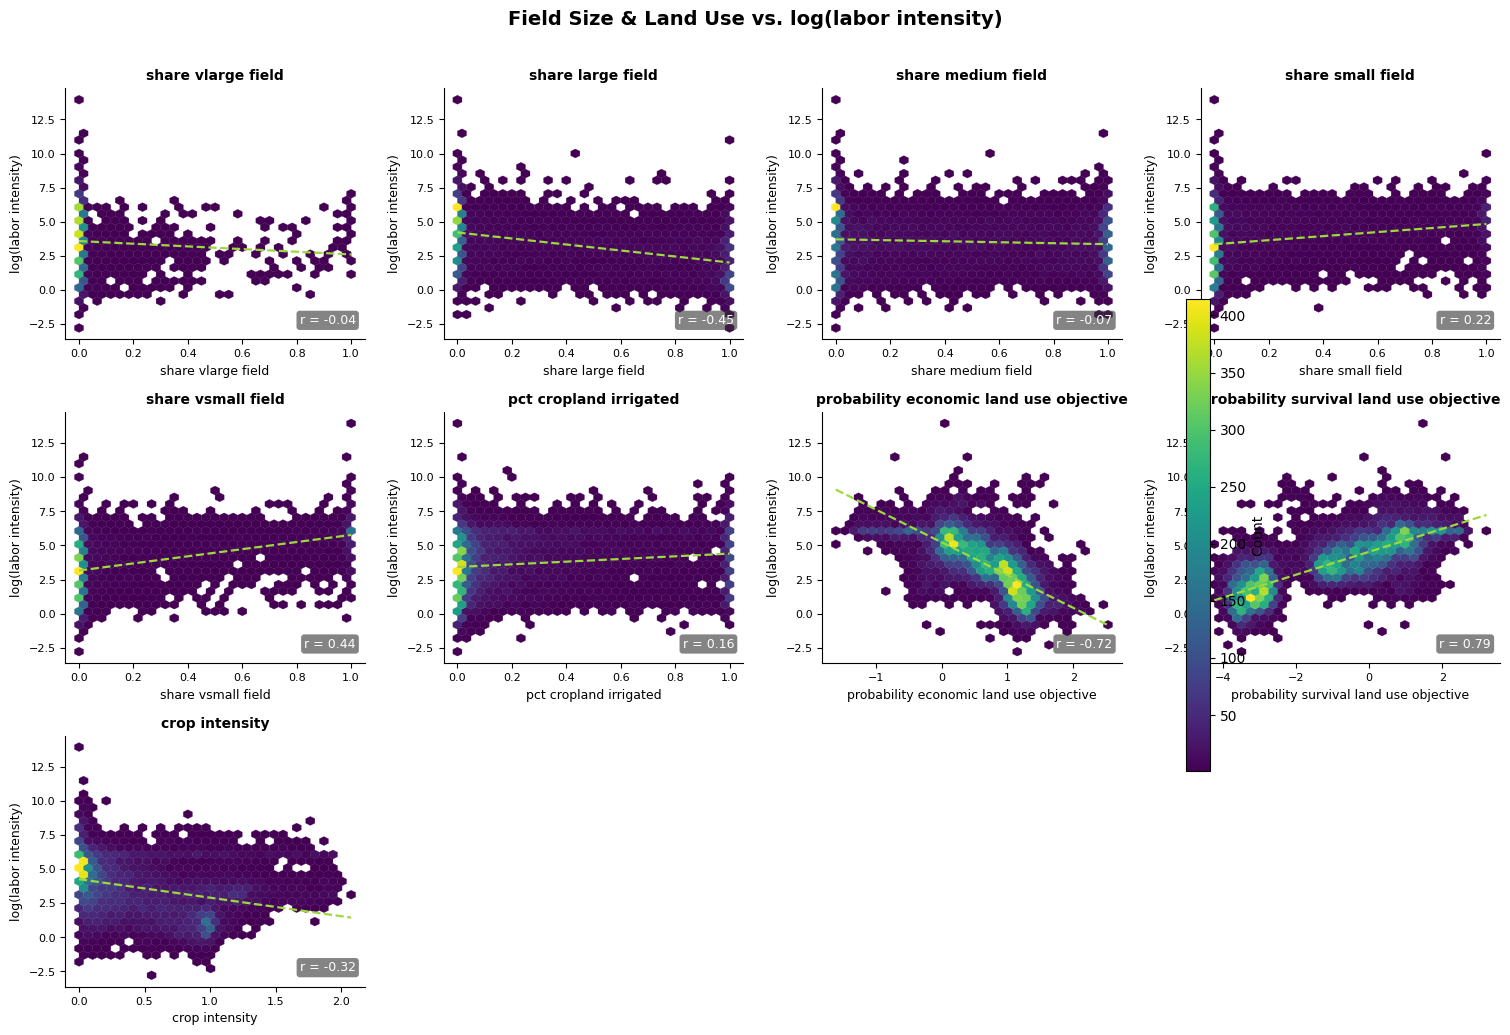

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_82831/2744293172.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


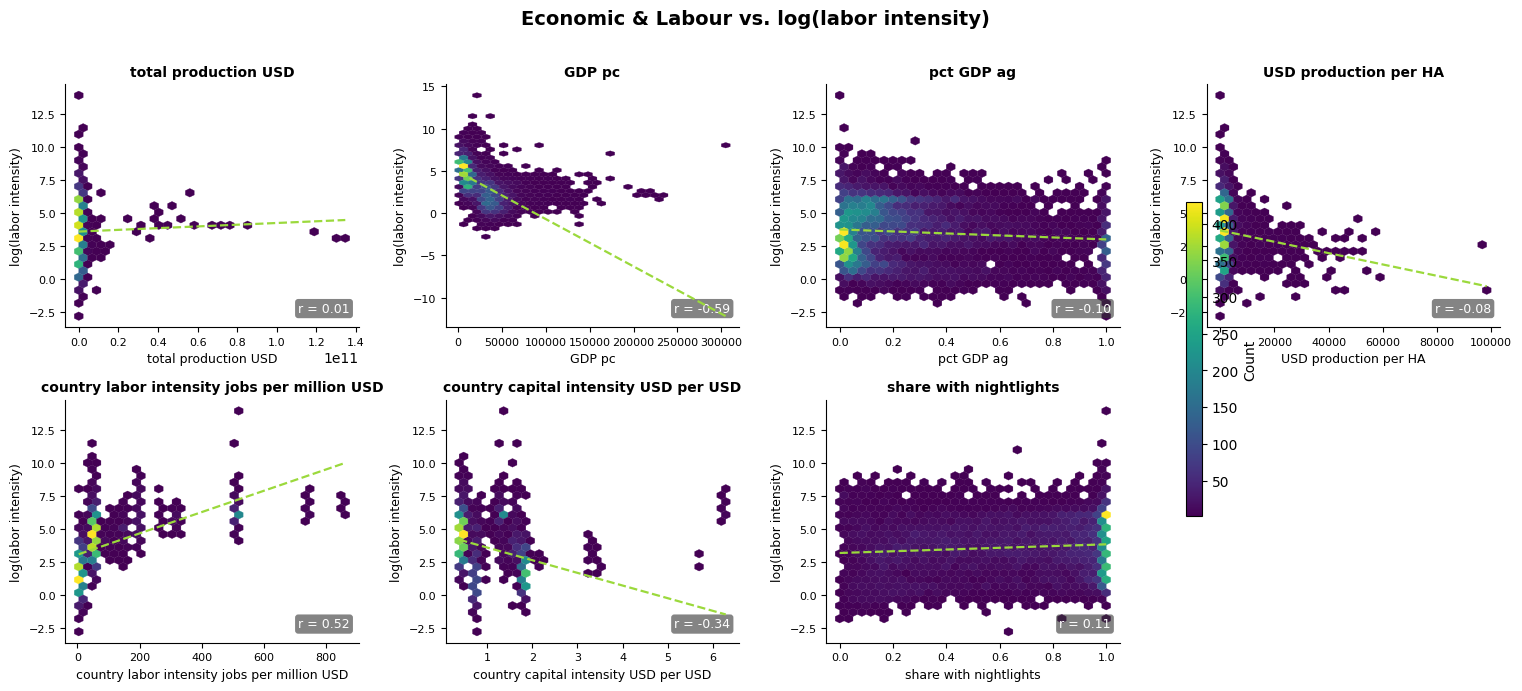

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_82831/2744293172.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


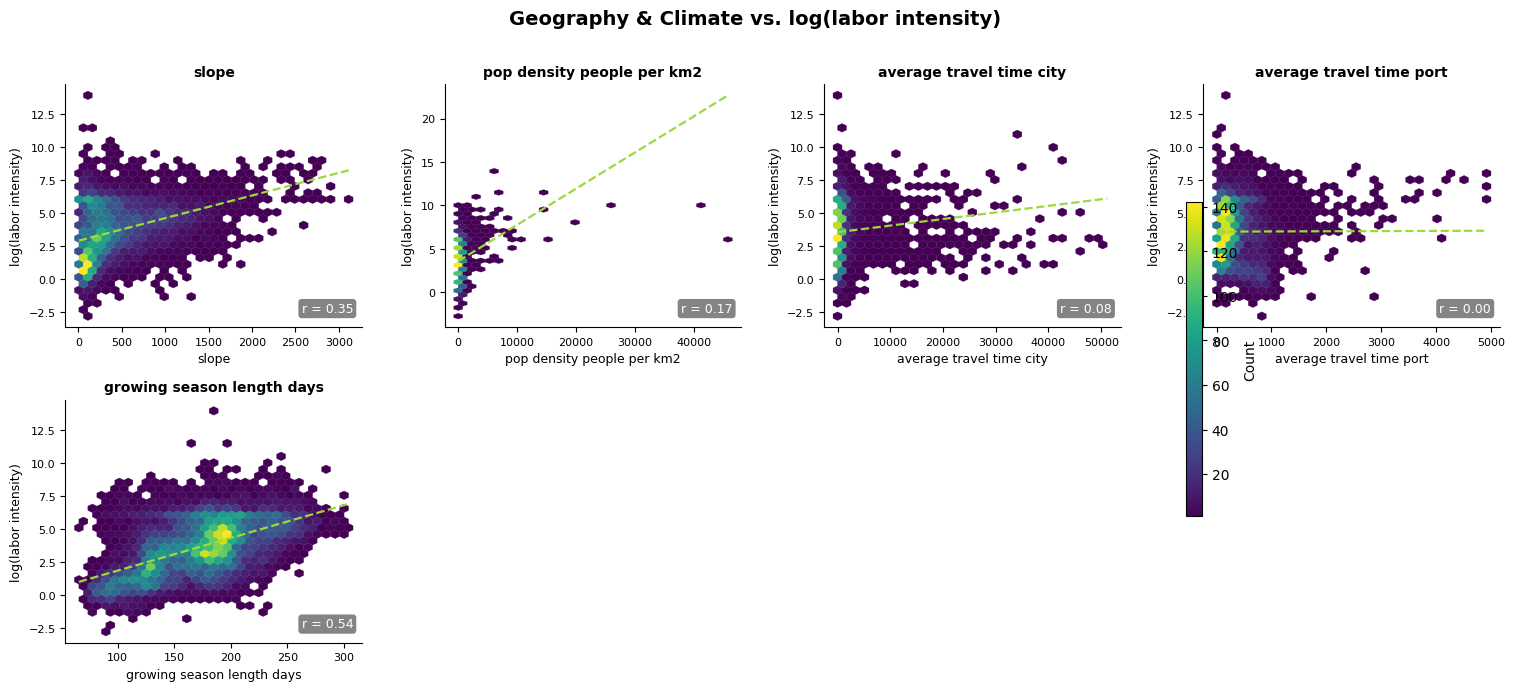

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_82831/2744293172.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


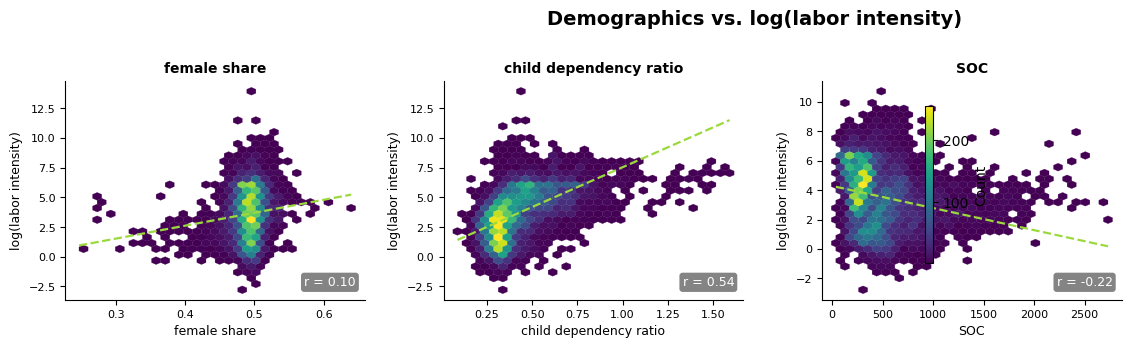

In [365]:
#### Generate figures 


# Add log-target column
model = 'labor'
TARGET = 'log_labor_intensity'  
labor_model[TARGET] = np.log(labor_model['labor_intensity_jobs_per_million_USD'])

for group_name, preds in GROUPS.items():
    if group_name == 'IDs / Keys':
        continue          
    plot_scatter_group(labor_model, model, TARGET, preds, group_name, ncols=4, fd=fd)